# Simulation of the Mass Balance Model

This notebook implements the body weight model proposed in

> **Arencibia-Albite, F.** *Serious analytical inconsistencies challenge the validity of the energy balance theory.* Heliyon (2020).

The model predicts changes in body weight based on daily mass intake and relative mass excretion.

## Body weight model

The average (steady-state) body weight is

$$
w_{\mathrm{avg}}
=
\frac{M}{R},
$$

where

- $M=\overline{\mathrm{EPM}}+\overline{\mathrm{nEPM}}$ is the average daily mass intake,
- $R$ is the average relative daily rate of mass excretion.

The body weight after $n$ consecutive days is approximated by

$$
w_{k+n}
=
\frac{M}{R}
+
\left(
w_k-\frac{M}{R}
\right)
(1-R)^n.
$$

The daily weight change is

$$
\Delta w
=
w_{k+n}-w_k.
$$

## Fat mass

Following Forbes' empirical relationship, the fat mass after $n$ days is approximated by

$$
FM_{k+n}
=
10.4\,
W\!\left(
\frac{FM_k}{10.4}
\exp\!\left(
\frac{w_{k+n}-w_k+FM_k}{10.4}
\right)
\right),
$$

where $W(\cdot)$ denotes the **Lambert W function**.

## Fat-free mass

Fat-free mass is obtained from

$$
FFM_{k+n}
=
w_{k+n}
-
FM_{k+n}.
$$

The following simulation illustrates the predicted evolution of body weight, fat mass and fat-free mass over time.

Initial equilibrium = 111.26 kg
New equilibrium     = 97.44 kg


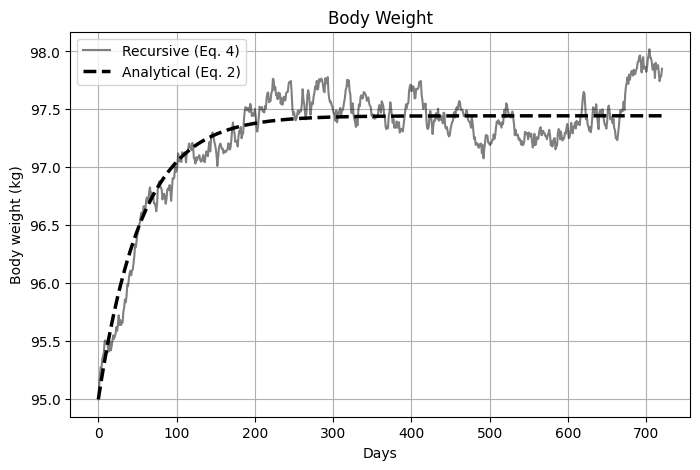

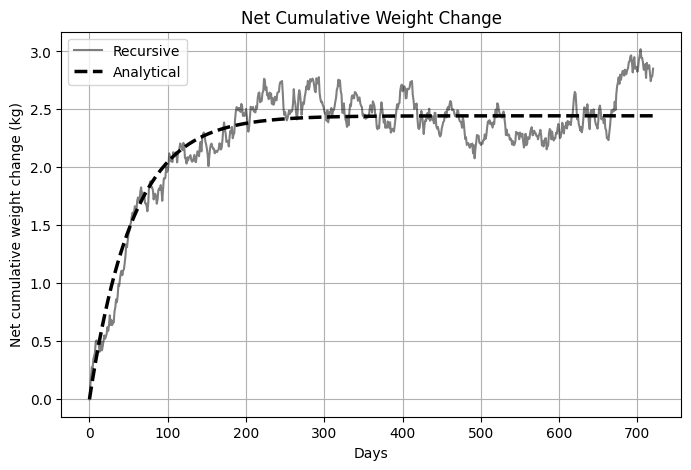

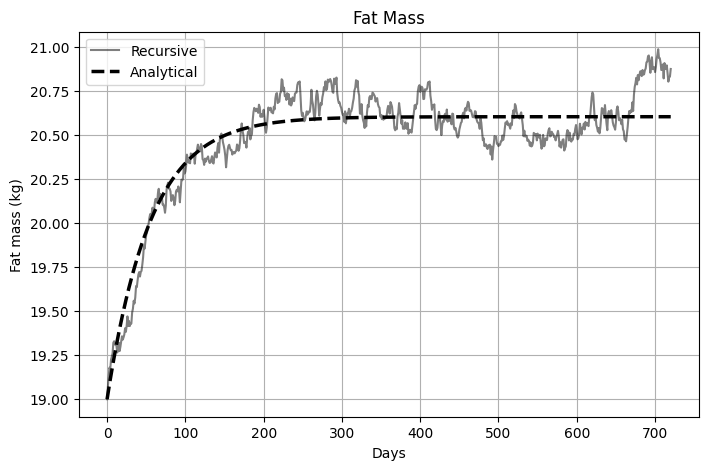

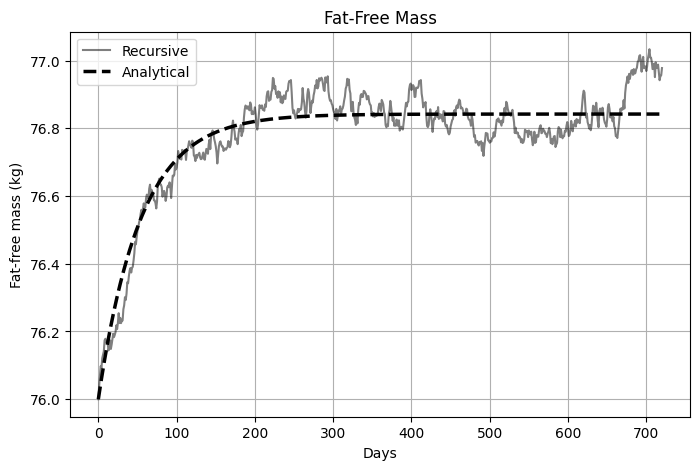

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

# =======================================================
# Arencibia-Albite (2020)
# Monte Carlo simulation of the Mass Balance Model
# =======================================================

# -------------------------------
# Parameters
# -------------------------------

days = 720
n = np.arange(days + 1)

# Initial body composition
w0 = 95.0          # kg
FM0 = 19.0          # kg

# Daily mass intake (kg/day)
EPM_old = 0.5287
EPM_new = 0.2800        # 55% reduction
nEPM = 1.474

# Relative daily mass excretion (% of k-th day weight)
R = 0.018

# Total daily intake
M_old = EPM_old + nEPM
M_new = EPM_new + nEPM

print(f"Initial equilibrium = {M_old/R:.2f} kg")
print(f"New equilibrium     = {M_new/R:.2f} kg")

# -------------------------------------------------------
# Recursive simulation (Eq. 4)
# -------------------------------------------------------

rng = np.random.default_rng(27)

sigma = 0.05      # kg/day

weight = np.zeros(days + 1)
weight[0] = w0

daily_M = rng.normal(
    loc=M_new,
    scale=sigma,
    size=days
)

for k in range(days):
    weight[k + 1] = daily_M[k] + (1 - R) * weight[k]

# -------------------------------------------------------
# Analytical solution (Eq. 2)
# -------------------------------------------------------

weight_det = (
    M_new / R
    + (w0 - M_new / R) * (1 - R) ** n
)

# -------------------------------------------------------
# Net cumulative weight change
# -------------------------------------------------------

ncw = weight - w0
ncw_det = weight_det - w0

# -------------------------------------------------------
# Fat mass (Eq. 6)
# -------------------------------------------------------

fat = np.real(
    10.4 *
    lambertw(
        (FM0 / 10.4) *
        np.exp((weight - w0 + FM0) / 10.4)
    )
)

fat_det = np.real(
    10.4 *
    lambertw(
        (FM0 / 10.4) *
        np.exp((weight_det - w0 + FM0) / 10.4)
    )
)

# -------------------------------------------------------
# Fat-free mass (Eq. 7)
# -------------------------------------------------------

ffm = weight - fat
ffm_det = weight_det - fat_det

# =======================================================
# Figure 2A : Body weight
# =======================================================

plt.figure(figsize=(8,5))

plt.plot(
    n,
    weight,
    color="black",
    alpha=0.5,
    lw=1.5,
    label="Recursive (Eq. 4)"
)

plt.plot(
    n,
    weight_det,
    "--",
    color="black",
    lw=2.5,
    label="Analytical (Eq. 2)"
)

plt.xlabel("Days")
plt.ylabel("Body weight (kg)")
plt.title("Body Weight")
plt.grid(True)
plt.legend()

# =======================================================
# Figure 2B : Net cumulative weight change
# =======================================================

plt.figure(figsize=(8,5))

plt.plot(
    n,
    ncw,
    color="black",
    alpha=0.5,
    lw=1.5,
    label="Recursive"
)

plt.plot(
    n,
    ncw_det,
    "--",
    color="black",
    lw=2.5,
    label="Analytical"
)

plt.xlabel("Days")
plt.ylabel("Net cumulative weight change (kg)")
plt.title("Net Cumulative Weight Change")
plt.grid(True)
plt.legend()

# =======================================================
# Figure 2C : Fat mass
# =======================================================

plt.figure(figsize=(8,5))

plt.plot(
    n,
    fat,
    color="black",
    alpha=0.5,
    lw=1.5,
    label="Recursive"
)

plt.plot(
    n,
    fat_det,
    "--",
    color="black",
    lw=2.5,
    label="Analytical"
)

plt.xlabel("Days")
plt.ylabel("Fat mass (kg)")
plt.title("Fat Mass")
plt.grid(True)
plt.legend()

# =======================================================
# Figure 2D : Fat-free mass
# =======================================================

plt.figure(figsize=(8,5))

plt.plot(
    n,
    ffm,
    color="black",
    alpha=0.5,
    lw=1.5,
    label="Recursive"
)

plt.plot(
    n,
    ffm_det,
    "--",
    color="black",
    lw=2.5,
    label="Analytical"
)

plt.xlabel("Days")
plt.ylabel("Fat-free mass (kg)")
plt.title("Fat-Free Mass")
plt.grid(True)
plt.legend()

plt.show()


Diet compositions (constant energy intake = 1300 kcal/day)

Daily energy intake (E_in) = 1300 kcal/day
HCLF
20/65/15
  Energy fractions : Fat 20%, Carbohydrate 65%, Protein 15%
  Fat          =   28.9 g/day
  Carbohydrate =  211.2 g/day
  Protein      =   48.8 g/day
  Total EPM    =  288.9 g/day

Daily energy intake (E_in) = 1300 kcal/day
Balanced
35/50/15
  Energy fractions : Fat 35%, Carbohydrate 50%, Protein 15%
  Fat          =   50.6 g/day
  Carbohydrate =  162.5 g/day
  Protein      =   48.8 g/day
  Total EPM    =  261.8 g/day

Daily energy intake (E_in) = 1300 kcal/day
HFLC
65/20/15
  Energy fractions : Fat 65%, Carbohydrate 20%, Protein 15%
  Fat          =   93.9 g/day
  Carbohydrate =   65.0 g/day
  Protein      =   48.8 g/day
  Total EPM    =  207.6 g/day

Daily energy intake (E_in) = 1300 kcal/day
HF-HP(mass)
50/15/35
  Mass fractions   : Fat 50%, Carbohydrate 15%, Protein 35%
  Fat          =  101.6 g/day
  Carbohydrate =   30.5 g/day
  Protein      =   71.1 g/day
  Total 

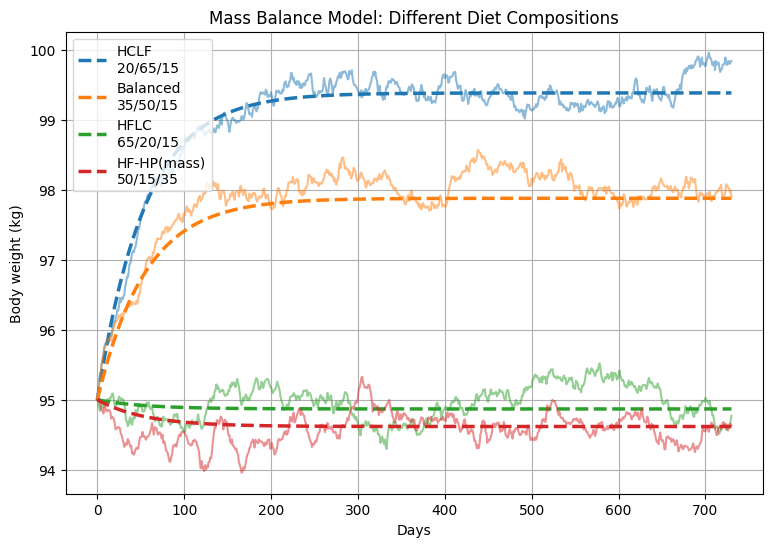

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

# ==========================================================
# Arencibia-Albite Mass Balance Model
# Comparison of different diet compositions
# ==========================================================

rng = np.random.default_rng(27)

# ----------------------------------------------------------
# Simulation parameters
# ----------------------------------------------------------

days = 730
n = np.arange(days + 1)

# Initial body composition
w0 = 95.0      # kg
FM0 = 19.0      # kg

# Daily energy intake (kept constant)
EI = 1300       # kcal/day

# Non-energy-providing mass
nEPM = 1.5    # kg/day

# Relative mass excretion (% of k-th day body weight)
R = 0.018

# Standard deviation of daily intake fluctuations
sigma = 0.05    # kg/day


# ----------------------------------------------------------
# Helper function
# ----------------------------------------------------------

def epm_from_energy(EI, fat_frac, carb_frac, protein_frac):
    """
    Convert macronutrient energy fractions into
    energy-providing mass (kg/day).
    """

    fat_g = EI * fat_frac / 9
    carb_g = EI * carb_frac / 4
    prot_g = EI * protein_frac / 4

    return (fat_g + carb_g + prot_g) / 1000


# ----------------------------------------------------------
# Diet definitions
# ----------------------------------------------------------

diets = {

    "HCLF\n20/65/15":
        epm_from_energy(EI, 0.20, 0.65, 0.15),

    "Balanced\n35/50/15":
        epm_from_energy(EI, 0.35, 0.50, 0.15),

    "HFLC\n65/20/15":
        epm_from_energy(EI, 0.65, 0.20, 0.15),

    # 48/4/48 MASS fractions
    "HF-HP(mass)\n50/15/35":
        (EI / (9*0.48 + 4*0.04 + 4*0.48)) / 1000
}

# ----------------------------------------------------------
# Simulate each diet
# ----------------------------------------------------------

# ----------------------------------------------------------
# Diet summary
# ----------------------------------------------------------

print("=" * 80)
print("Diet compositions (constant energy intake = {:.0f} kcal/day)".format(EI))
print("=" * 80)
print()

for name, EPM in diets.items():

    # Convert back to grams/day
    epm_g = EPM * 1000

    print(f"Daily energy intake (E_in) = {EI:.0f} kcal/day")

    if "HCLF" in name:
        fat, carb, prot = 0.20, 0.65, 0.15

        fat_g  = EI * fat / 9
        carb_g = EI * carb / 4
        prot_g = EI * prot / 4

        print(f"{name}")
        print(f"  Energy fractions : Fat {fat:.0%}, Carbohydrate {carb:.0%}, Protein {prot:.0%}")
        print(f"  Fat          = {fat_g:6.1f} g/day")
        print(f"  Carbohydrate = {carb_g:6.1f} g/day")
        print(f"  Protein      = {prot_g:6.1f} g/day")
        print(f"  Total EPM    = {epm_g:6.1f} g/day")
        print()

    elif "Balanced" in name:
        fat, carb, prot = 0.35, 0.50, 0.15

        fat_g  = EI * fat / 9
        carb_g = EI * carb / 4
        prot_g = EI * prot / 4

        print(f"{name}")
        print(f"  Energy fractions : Fat {fat:.0%}, Carbohydrate {carb:.0%}, Protein {prot:.0%}")
        print(f"  Fat          = {fat_g:6.1f} g/day")
        print(f"  Carbohydrate = {carb_g:6.1f} g/day")
        print(f"  Protein      = {prot_g:6.1f} g/day")
        print(f"  Total EPM    = {epm_g:6.1f} g/day")
        print()

    elif "HFLC" in name:
        fat, carb, prot = 0.65, 0.20, 0.15

        fat_g  = EI * fat / 9
        carb_g = EI * carb / 4
        prot_g = EI * prot / 4

        print(f"{name}")
        print(f"  Energy fractions : Fat {fat:.0%}, Carbohydrate {carb:.0%}, Protein {prot:.0%}")
        print(f"  Fat          = {fat_g:6.1f} g/day")
        print(f"  Carbohydrate = {carb_g:6.1f} g/day")
        print(f"  Protein      = {prot_g:6.1f} g/day")
        print(f"  Total EPM    = {epm_g:6.1f} g/day")
        print()

    else:
        # 50/15/35 MASS fractions
        total_mass = epm_g

        fat_g = 0.50 * total_mass
        carb_g = 0.15 * total_mass
        prot_g = 0.35 * total_mass

        # Corresponding energy fractions
        fat_kcal = 9 * fat_g
        carb_kcal = 4 * carb_g
        prot_kcal = 4 * prot_g

        total_kcal = fat_kcal + carb_kcal + prot_kcal

        print(f"{name}")
        print("  Mass fractions   : Fat 50%, Carbohydrate 15%, Protein 35%")
        print(f"  Fat          = {fat_g:6.1f} g/day")
        print(f"  Carbohydrate = {carb_g:6.1f} g/day")
        print(f"  Protein      = {prot_g:6.1f} g/day")
        print(f"  Total EPM    = {epm_g:6.1f} g/day")
        print()
        print("  Equivalent energy fractions:")
        print(f"    Fat          = {fat_kcal/total_kcal:.1%}")
        print(f"    Carbohydrate = {carb_kcal/total_kcal:.1%}")
        print(f"    Protein      = {prot_kcal/total_kcal:.1%}")
        print()

print("=" * 80)
print()

plt.figure(figsize=(9,6))

for name, EPM in diets.items():

    M_mean = EPM + nEPM

    # -----------------------------
    # Stochastic simulation
    # -----------------------------
    daily_M = rng.normal(
        loc=M_mean,
        scale=sigma,
        size=days
    )

    weight = np.zeros(days + 1)
    weight[0] = w0

    for k in range(days):
        weight[k+1] = daily_M[k] + (1-R) * weight[k]

    # -----------------------------
    # Analytical expectation
    # -----------------------------
    weight_det = (
        M_mean / R
        + (w0 - M_mean / R) * (1 - R) ** n
    )

    # -----------------------------
    # Plot
    # -----------------------------
        # Analytical expectation (Eq. 2)
    weight_det = (
        M_mean / R
        + (w0 - M_mean / R) * (1 - R) ** n
    )

    # Plot stochastic realization
    line, = plt.plot(
        n,
        weight,
        lw=1.5,
        alpha=0.5
    )

    # Overlay analytical expectation
    plt.plot(
        n,
        weight_det,
        '--',
        color=line.get_color(),
        lw=2.5,
        label=name
    )

plt.xlabel("Days")
plt.ylabel("Body weight (kg)")
plt.title("Mass Balance Model: Different Diet Compositions")
plt.grid(True)
plt.legend()

plt.show()